# Demo: Evaluation on FluVaccine v0

Access data here: https://huggingface.co/datasets/jmaasch/compositional_causal_reasoning

This demo provides a walk-through of:
1. How to use the FluVaccine datasets for CCR evaluation.
   - Standard metrics: F1, accuracy, precision, recall.
   - Metrics for counterfactual reasoning evaluation: external validity RAE and internal consistency RAE.
2. How to generate new random FluVaccine tasks.

For more information on the counterfactual reasoning metrics, see [Maasch et al. 2025 (ICML)](https://arxiv.org/abs/2503.04556).

Code by Jacqueline Maasch | April 2025

In [1]:
# General importations.
import pandas as pd
import numpy as np
import os
import sys
from ast import literal_eval
from sklearn.metrics import f1_score,precision_score,recall_score,accuracy_score

sys.path.insert(1, os.path.join(sys.path[0], '..'))
from utils import Utils
from flu_vaccine import FluVaccine

In [2]:
u = Utils()

In [3]:
path = "../static_datasets/flu_vaccine_v0/"

## Import static datasets

In [4]:
# Load raw data.
df = pd.read_csv(path+"flu_vaccine_v0.csv")
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Task ID                                 30000 non-null  object
 1   Context ID                              30000 non-null  int64 
 2   Sample ID                               30000 non-null  int64 
 3   Nodes per BCC                           30000 non-null  object
 4   Replicate ID                            30000 non-null  int64 
 5   DAG adjacency matrix                    30000 non-null  object
 6   DAG nodes                               30000 non-null  object
 7   CCT adjacency matrix                    30000 non-null  object
 8   CCT nodes                               30000 non-null  object
 9   Exogenous variables                     30000 non-null  object
 10  Bernoulli parameters                    30000 non-null  object
 11  Gl

,Task ID,Context ID,Sample ID,Nodes per BCC,Replicate ID,DAG adjacency matrix,DAG nodes,CCT adjacency matrix,CCT nodes,Exogenous variables,Bernoulli parameters,Global quantity,Local quantities,Compositions,Causal context,Sample context,Factual queries,Interventional queries (cause = True),Interventional queries (cause = False)
0,0.0.0,0,0,"[6, 4, 6]",0,[[0 1 0 0 0 1 0 0 0 0 0 0 0 0]\n [0 0 1 0 0 0 ...,"['Melany', 'Lauri', 'Kaci', 'Elda', 'Karly', '...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['Melany', 'Jonnie', 'Lilie', 'Dahlia']","['RAZQ', '3PY4', 'I4KS', 'QT1I', 'FRNR', 'MMFX...","[0.7, 0.7, 0.5, 0.7, 0.8, 0.7, 0.7, 0.5, 0.8, ...","('Melany', 'Dahlia')","[('Melany', 'Jonnie'), ('Melany', 'Lilie'), ('...","[[('Melany', 'Jonnie'), ('Jonnie', 'Lilie'), (...",A group of friends is considering whether or n...,"During the previous flu season, Melany had a ...",{'Dahlia': {'Prompt': 'Did Dahlia get vaccinat...,"{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos...","{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos..."
1,0.0.1,0,0,"[6, 4, 6]",1,[[0 1 0 0 0 1 0 0 0 0 0 0 0 0]\n [0 0 1 0 0 0 ...,"['Melany', 'Lauri', 'Kaci', 'Elda', 'Karly', '...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['Melany', 'Jonnie', 'Lilie', 'Dahlia']","['RAZQ', '3PY4', 'I4KS', 'QT1I', 'FRNR', 'MMFX...","[0.7, 0.7, 0.5, 0.7, 0.8, 0.7, 0.7, 0.5, 0.8, ...","('Melany', 'Dahlia')","[('Melany', 'Jonnie'), ('Melany', 'Lilie'), ('...","[[('Melany', 'Jonnie'), ('Jonnie', 'Lilie'), (...",A group of friends is considering whether or n...,"During the previous flu season, Melany had a ...",{'Dahlia': {'Prompt': 'Did Dahlia get vaccinat...,"{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos...","{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos..."
2,0.0.2,0,0,"[6, 4, 6]",2,[[0 1 0 0 0 1 0 0 0 0 0 0 0 0]\n [0 0 1 0 0 0 ...,"['Melany', 'Lauri', 'Kaci', 'Elda', 'Karly', '...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['Melany', 'Jonnie', 'Lilie', 'Dahlia']","['RAZQ', '3PY4', 'I4KS', 'QT1I', 'FRNR', 'MMFX...","[0.7, 0.7, 0.5, 0.7, 0.8, 0.7, 0.7, 0.5, 0.8, ...","('Melany', 'Dahlia')","[('Melany', 'Jonnie'), ('Melany', 'Lilie'), ('...","[[('Melany', 'Jonnie'), ('Jonnie', 'Lilie'), (...",A group of friends is considering whether or n...,"During the previous flu season, Melany had a ...",{'Dahlia': {'Prompt': 'Did Dahlia get vaccinat...,"{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos...","{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos..."
3,0.0.3,0,0,"[6, 4, 6]",3,[[0 1 0 0 0 1 0 0 0 0 0 0 0 0]\n [0 0 1 0 0 0 ...,"['Melany', 'Lauri', 'Kaci', 'Elda', 'Karly', '...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['Melany', 'Jonnie', 'Lilie', 'Dahlia']","['RAZQ', '3PY4', 'I4KS', 'QT1I', 'FRNR', 'MMFX...","[0.7, 0.7, 0.5, 0.7, 0.8, 0.7, 0.7, 0.5, 0.8, ...","('Melany', 'Dahlia')","[('Melany', 'Jonnie'), ('Melany', 'Lilie'), ('...","[[('Melany', 'Jonnie'), ('Jonnie', 'Lilie'), (...",A group of friends is considering whether or n...,"During the previous flu season, Melany had a ...",{'Dahlia': {'Prompt': 'Did Dahlia get vaccinat...,"{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos...","{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos..."
4,0.0.4,0,0,"[6, 4, 6]",4,[[0 1 0 0 0 1 0 0 0 0 0 0 0 0]\n [0 0 1 0 0 0 ...,"['Melany', 'Lauri', 'Kaci', 'Elda', 'Karly', '...",[[0 1 1 1]\n [0 0 1 1]\n [0 0 0 1]\n [0 0 0 0]],"['Melany', 'Jonnie', 'Lilie', 'Dahlia']","['RAZQ', '3PY4', 'I4KS', 'QT1I', 'FRNR', 'MMFX...","[0.7, 0.7, 0.5, 0.7, 0.8, 0.7, 0.7, 0.5, 0.8, ...","('Melany', 'Dahlia')","[('Melany', 'Jonnie'), ('Melany', 'Lilie'), ('...","[[('Melany', 'Jonnie'), ('Jonnie', 'Lilie'), (...",A group of friends is considering whether or n...,"During the previous flu season, Melany had a ...",{'Dahlia': {'Prompt': 'Did Dahlia get vaccinat...,"{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos...","{('Melany', 'Dahlia'): {'Prompt': 'Now, suppos..."


In [5]:
# Convert adjacency matrices back to numpy arrays.
def string_to_array(array_string):
    cleaned_string = array_string.replace('\n', '')
    cleaned_string = cleaned_string.replace(' ', ', ')
    new_list = literal_eval(cleaned_string)
    return np.array(new_list)

print(string_to_array(df["DAG adjacency matrix"][0]))

df["DAG adjacency matrix"] = df["DAG adjacency matrix"].apply(string_to_array)

[[0 1 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [6]:
# Total observations per Context ID.
df["Context ID"].value_counts()

Context ID
0    10000
1    10000
2    10000
Name: count, dtype: int64

In [7]:
# Total observations per graph size.
df["Nodes per BCC"].value_counts()

Nodes per BCC
[6, 4, 6]    10000
[7, 5, 7]    10000
[8, 6, 8]    10000
Name: count, dtype: int64

In [8]:
# Load factual prompts.
df_f = pd.read_csv(path+"flu_vaccine_factual_v0.csv")
print(df_f.info())
display(df_f.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Task ID        90000 non-null  object
 1   Context ID     90000 non-null  int64 
 2   Sample ID      90000 non-null  int64 
 3   Replicate ID   90000 non-null  int64 
 4   Nodes per BCC  90000 non-null  object
 5   Effect         90000 non-null  object
 6   Context        90000 non-null  object
 7   Question       90000 non-null  object
 8   True           90000 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 6.2+ MB
None


,Task ID,Context ID,Sample ID,Replicate ID,Nodes per BCC,Effect,Context,Question,True
0,0.0.0,0,0,0,"[6, 4, 6]",Dahlia,A group of friends is considering whether or n...,Did Dahlia get vaccinated? Begin your response...,0
1,0.0.0,0,0,0,"[6, 4, 6]",Jonnie,A group of friends is considering whether or n...,Did Jonnie get vaccinated? Begin your response...,1
2,0.0.0,0,0,0,"[6, 4, 6]",Lilie,A group of friends is considering whether or n...,Did Lilie get vaccinated? Begin your response ...,1
3,0.0.1,0,0,1,"[6, 4, 6]",Dahlia,A group of friends is considering whether or n...,Did Dahlia get vaccinated? Begin your response...,0
4,0.0.1,0,0,1,"[6, 4, 6]",Jonnie,A group of friends is considering whether or n...,Did Jonnie get vaccinated? Begin your response...,1


In [9]:
# Load counterfactual prompts.
df_cf = pd.read_csv(path+"flu_vaccine_counterfactual_v0.csv")
print(df_cf.info())
display(df_cf.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Task ID                   180000 non-null  object
 1   Context ID                180000 non-null  int64 
 2   Sample ID                 180000 non-null  int64 
 3   Replicate ID              180000 non-null  int64 
 4   Nodes per BCC             180000 non-null  object
 5   Cause-effect pair         180000 non-null  object
 6   Cause                     180000 non-null  object
 7   Effect                    180000 non-null  object
 8   Context                   180000 non-null  object
 9   Question (cause = True)   180000 non-null  object
 10  True (cause = True)       180000 non-null  int64 
 11  Question (cause = False)  180000 non-null  object
 12  True (cause = False)      180000 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 17.9+ MB
None


,Task ID,Context ID,Sample ID,Replicate ID,Nodes per BCC,Cause-effect pair,Cause,Effect,Context,Question (cause = True),True (cause = True),Question (cause = False),True (cause = False)
0,0.0.0,0,0,0,"[6, 4, 6]","('Melany', 'Dahlia')",Melany,Dahlia,A group of friends is considering whether or n...,"Now, suppose that Melany got vaccinated regard...",0,"Now, suppose that Melany did not get vaccinate...",0
1,0.0.0,0,0,0,"[6, 4, 6]","('Melany', 'Jonnie')",Melany,Jonnie,A group of friends is considering whether or n...,"Now, suppose that Melany got vaccinated regard...",1,"Now, suppose that Melany did not get vaccinate...",0
2,0.0.0,0,0,0,"[6, 4, 6]","('Melany', 'Lilie')",Melany,Lilie,A group of friends is considering whether or n...,"Now, suppose that Melany got vaccinated regard...",1,"Now, suppose that Melany did not get vaccinate...",1
3,0.0.0,0,0,0,"[6, 4, 6]","('Jonnie', 'Lilie')",Jonnie,Lilie,A group of friends is considering whether or n...,"Now, suppose that Jonnie got vaccinated regard...",1,"Now, suppose that Jonnie did not get vaccinate...",1
4,0.0.0,0,0,0,"[6, 4, 6]","('Jonnie', 'Dahlia')",Jonnie,Dahlia,A group of friends is considering whether or n...,"Now, suppose that Jonnie got vaccinated regard...",0,"Now, suppose that Jonnie did not get vaccinate...",0


In [10]:
# Load ground truth PNS values.
pns_dict = np.load(path+"flu_vaccine_pns_dict_v0.npy",
                   allow_pickle = "TRUE").item()
display(pns_dict)

{0: {"('Melany', 'Dahlia')": 0.0065,
  "('Melany', 'Jonnie')": 0.1575,
  "('Melany', 'Lilie')": 0.023,
  "('Jonnie', 'Lilie')": 0.132,
  "('Jonnie', 'Dahlia')": 0.0445,
  "('Lilie', 'Dahlia')": 0.3055,
  "[('Melany', 'Jonnie'), ('Jonnie', 'Lilie'), ('Lilie', 'Dahlia')]": 0.0063513449999999996,
  "[('Melany', 'Jonnie'), ('Jonnie', 'Dahlia')]": 0.007008749999999999,
  "[('Melany', 'Lilie'), ('Lilie', 'Dahlia')]": 0.0070265},
 1: {"('Armida', 'Keesha')": 0.0645,
  "('Armida', 'Oney')": 0.355,
  "('Armida', 'Alvera')": 0.2195,
  "('Oney', 'Alvera')": 0.612,
  "('Oney', 'Keesha')": 0.1675,
  "('Alvera', 'Keesha')": 0.2865,
  "[('Armida', 'Oney'), ('Oney', 'Alvera'), ('Alvera', 'Keesha')]": 0.062244989999999986,
  "[('Armida', 'Oney'), ('Oney', 'Keesha')]": 0.0594625,
  "[('Armida', 'Alvera'), ('Alvera', 'Keesha')]": 0.06288674999999999},
 2: {"('Lady', 'Bella')": 0.076,
  "('Lady', 'Riya')": 0.275,
  "('Lady', 'Scarlet')": 0.16,
  "('Riya', 'Scarlet')": 0.565,
  "('Riya', 'Bella')": 0.275,


In [11]:
# Load thresholds for internal consistency evaluation.
# By default, the multiplier was 1.0
# Here, we want a multiplier of 1.1, so we will update these values later.
threshold_dict = np.load(path+"flu_vaccine_threshold_dict_v0.npy",
                         allow_pickle = "TRUE").item()
display(threshold_dict)

{0: {"[('Melany', 'Jonnie'), ('Jonnie', 'Lilie'), ('Lilie', 'Dahlia')]": 0.022870000000000022,
  "[('Melany', 'Jonnie'), ('Jonnie', 'Dahlia')]": 0.07826923076923072,
  "[('Melany', 'Lilie'), ('Lilie', 'Dahlia')]": 0.08100000000000002},
 1: {"[('Armida', 'Oney'), ('Oney', 'Alvera'), ('Alvera', 'Keesha')]": 0.03496139534883745,
  "[('Armida', 'Oney'), ('Oney', 'Keesha')]": 0.07810077519379845,
  "[('Armida', 'Alvera'), ('Alvera', 'Keesha')]": 0.025011627906976905},
 2: {"[('Lady', 'Riya'), ('Riya', 'Scarlet'), ('Scarlet', 'Bella')]": 0.02686184210526318,
  "[('Lady', 'Riya'), ('Riya', 'Bella')]": 0.004934210526315611,
  "[('Lady', 'Scarlet'), ('Scarlet', 'Bella')]": 0.002105263157894651}}

## Simulate evaluation and error analysis

Subsample a single Context ID. For illustration, we will focus on Context 0.

In [12]:
# Sample Context 0.
df_0 = df[df["Context ID"] == 0]
df_f_0 = df_f[df_f["Context ID"] == 0]
df_cf_0 = df_cf[df_cf["Context ID"] == 0]

print(len(df_0))
print(len(df_f_0))
print(len(df_cf_0))

10000
30000
60000


In [13]:
df_0.columns

Index(['Task ID', 'Context ID', 'Sample ID', 'Nodes per BCC', 'Replicate ID',
       'DAG adjacency matrix', 'DAG nodes', 'CCT adjacency matrix',
       'CCT nodes', 'Exogenous variables', 'Bernoulli parameters',
       'Global quantity', 'Local quantities', 'Compositions', 'Causal context',
       'Sample context', 'Factual queries',
       'Interventional queries (cause = True)',
       'Interventional queries (cause = False)'],
      dtype='object')

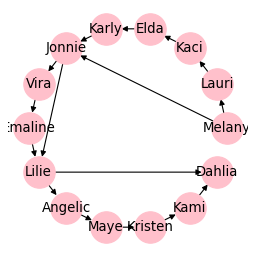

In [14]:
# View causal DAG (endogenous variables only).
u.plot_nx(df_0["DAG adjacency matrix"][0],
          labels = literal_eval(df_0["DAG nodes"][0]),
          figsize = (3,3), 
          dpi = 80)

### Associational level: Evaluate factual responses

In [15]:
# Perturb true responses to obtain synthetic predictions.
f_true = df_f_0["True"].to_numpy()
idx = np.random.choice(np.arange(len(f_true)), size = int(len(f_true)/100), replace = False)
f_pred = [f_true[i] if i not in idx else 1-f_true[i] for i in range(len(f_true))]
print(sum(np.where(f_pred != f_true, True, False)))

300


In [16]:
# Treat responses for all effects as one long vector.
# A finer-grained analysis would compute metrics separately for each effect.
print("F1        =", f1_score(f_true, f_pred))
print("Precision =", precision_score(f_true, f_pred))
print("Recall    =", recall_score(f_true, f_pred))
print("Accuracy  =", accuracy_score(f_true, f_pred))

F1        = 0.9933339258732558
Precision = 0.9959009089288897
Recall    = 0.9907801418439717
Accuracy  = 0.99


### Interventional level: Evaluate interventional responses

In [17]:
# Intervention (cause = True).
do_1_true = df_cf_0["True (cause = True)"].to_numpy()
idx = np.random.choice(np.arange(len(do_1_true)), size = int(len(do_1_true)/100), replace = False)
do_1_pred = [do_1_true[i] if i not in idx else 1-do_1_true[i] for i in range(len(do_1_true))]
print(sum(np.where(do_1_pred != do_1_true, True, False)))

600


In [18]:
# Treat responses for all cause-effect pairs as one long vector.
# A finer-grained analysis would compute metrics separately for each cause-effect pair.
print("F1        =", f1_score(do_1_true, do_1_pred))
print("Precision =", precision_score(do_1_true, do_1_pred))
print("Recall    =", recall_score(do_1_true, do_1_pred))
print("Accuracy  =", accuracy_score(do_1_true, do_1_pred))

F1        = 0.992317738342168
Precision = 0.9952230526234687
Recall    = 0.9894293374186136
Accuracy  = 0.99


In [19]:
# Intervention (cause = False).
do_0_true = df_cf_0["True (cause = False)"].to_numpy()
idx = np.random.choice(np.arange(len(do_0_true)), size = int(len(do_0_true)/100), replace = False)
do_0_pred = [do_0_true[i] if i not in idx else 1-do_0_true[i] for i in range(len(do_0_true))]
print(sum(np.where(do_0_pred != do_0_true, True, False)))

600


In [20]:
# Treat responses for all cause-effect pairs as one long vector.
# A finer-grained analysis would compute metrics separately for each cause-effect pair.
print("F1        =", f1_score(do_0_true, do_0_pred))
print("Precision =", precision_score(do_0_true, do_0_pred))
print("Recall    =", recall_score(do_0_true, do_0_pred))
print("Accuracy  =", accuracy_score(do_0_true, do_0_pred))

F1        = 0.9907501618721672
Precision = 0.9920348244882837
Recall    = 0.9894688221709007
Accuracy  = 0.99


### Counterfactual level: Evaluate PNS external validity and internal consistency

#### External validity of individual causal quantities

In [21]:
# Compute PNS estimates for each cause-effect pair.
# For illustration, we will demonstrate on (Melany,Dahlia).
df_pred = pd.DataFrame({"Cause = True": do_1_pred, 
                        "Cause = False": do_0_pred})
pns_pred = u.get_pns_direct(df_pred,
                            y_do_x1 = "Cause = True", 
                            y_do_x0 = "Cause = False")
pns_true = pns_dict.get(0).get("('Melany', 'Dahlia')")
external_validity_rae = u.get_rae(pns_true, pns_pred)

print("True PNS              =", pns_true)
print("Predicted PNS         =", pns_pred)
print("External validity RAE =", external_validity_rae)

True PNS              = 0.0065
Predicted PNS         = 0.11805
External validity RAE = 17.161538461538463


In [22]:
df_pred

,Cause = True,Cause = False
0,0,0
1,1,0
2,1,1
3,1,1
4,0,0
...,...,...
59995,1,0
59996,1,1
59997,1,1
59998,0,0


In [23]:
pns_dict.get(0)

{"('Melany', 'Dahlia')": 0.0065,
 "('Melany', 'Jonnie')": 0.1575,
 "('Melany', 'Lilie')": 0.023,
 "('Jonnie', 'Lilie')": 0.132,
 "('Jonnie', 'Dahlia')": 0.0445,
 "('Lilie', 'Dahlia')": 0.3055,
 "[('Melany', 'Jonnie'), ('Jonnie', 'Lilie'), ('Lilie', 'Dahlia')]": 0.0063513449999999996,
 "[('Melany', 'Jonnie'), ('Jonnie', 'Dahlia')]": 0.007008749999999999,
 "[('Melany', 'Lilie'), ('Lilie', 'Dahlia')]": 0.0070265}

#### Internal consistency and external validity of compositions

In [24]:
%%capture
# Compute PNS for composition.
# We will perturb the true values to simulate LM responses with errors.
df_m_j = df_cf_0[df_cf_0["Cause-effect pair"] == "('Melany', 'Jonnie')"]
idx = np.random.choice(np.arange(len(df_m_j)), size = int(len(df_m_j)/100), replace = False)
true = df_m_j["True (cause = True)"].to_numpy()
df_m_j["Pred (cause = True)"] = [true[i] if i not in idx else 1-true[i] for i in range(len(true))]

idx = np.random.choice(np.arange(len(df_m_j)), size = int(len(df_m_j)/100), replace = False)
true = df_m_j["True (cause = False)"].to_numpy()
df_m_j["Pred (cause = False)"] = [true[i] if i not in idx else 1-true[i] for i in range(len(true))]

pns_m_j = u.get_pns_direct(df_m_j,
                           y_do_x1 = "Pred (cause = True)", 
                           y_do_x0 = "Pred (cause = False)")

df_j_d = df_cf_0[df_cf_0["Cause-effect pair"] == "('Jonnie', 'Dahlia')"]
idx = np.random.choice(np.arange(len(df_m_j)), size = int(len(df_m_j)/100), replace = False)
true = df_j_d["True (cause = True)"].to_numpy()
df_j_d["Pred (cause = True)"] = [true[i] if i not in idx else 1-true[i] for i in range(len(true))]

true = df_j_d["True (cause = False)"].to_numpy()
idx = np.random.choice(np.arange(len(df_m_j)), size = int(len(df_m_j)/100), replace = False)
df_j_d["Pred (cause = False)"] = [true[i] if i not in idx else 1-true[i] for i in range(len(true))]

pns_j_d = u.get_pns_direct(df_j_d,
                           y_do_x1 = "Pred (cause = True)", 
                           y_do_x0 = "Pred (cause = False)")

In [25]:
# Compute RAE for external validity.
comp_true = pns_dict.get(0).get("[('Melany', 'Jonnie'), ('Jonnie', 'Dahlia')]")
comp_pred = pns_m_j*pns_j_d
external_validity_rae = u.get_rae(comp_true, comp_pred)
print("External validity RAE =", external_validity_rae)

# Compare to a threshold for validity.
thresh = 0.1
print("Desired RAE threshold =", thresh)
print("RAE <= threshold:", external_validity_rae <= thresh)

External validity RAE = 0.1916019261637241
Desired RAE threshold = 0.1
RAE <= threshold: False


In [26]:
pns_dict.get(0).get("[('Melany', 'Jonnie'), ('Jonnie', 'Dahlia')]")

0.007008749999999999

In [27]:
# Compute RAE for internal consistency.
internal_consistency_rae = u.get_rae(pns_pred, comp_pred)
print("Internal consistency RAE =", internal_consistency_rae)

# Compare to pre-defined threshold.
# We will use a multiplier on the threshold to be generous.
thresh = threshold_dict.get(0).get("[('Melany', 'Jonnie'), ('Jonnie', 'Dahlia')]")
thresh *= 1.25
print("Desired RAE threshold =", thresh)
print("RAE <= threshold:", internal_consistency_rae <= thresh)

Internal consistency RAE = 0.9292533672172808
Desired RAE threshold = 0.09783653846153839
RAE <= threshold: False


## Generate new tasks

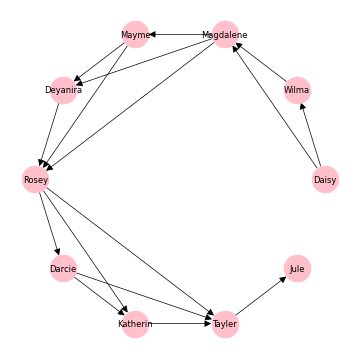


Causal context: A group of friends is considering whether or not to get vaccinated against the flu this year. Daisy will get vaccinated if she had a high fever or bronchitis for at least 5 days in the previous flu season. Wilma will get vaccinated if she had a high fever or bronchitis for at least 6 days in the previous flu season or if Daisy gets vaccinated. Magdalene will get vaccinated if she had a high fever or bronchitis for at least 5 days in the previous flu season and Daisy gets vaccinated and Wilma gets vaccinated. Mayme will get vaccinated if she had a high fever or bronchitis for at least 7 days in the previous flu season and Magdalene gets vaccinated. Deyanira will get vaccinated if she had a high fever or bronchitis for at least 5 days in the previous flu season or if Magdalene gets vaccinated or if Mayme gets vaccinated. Rosey will get vaccinated if she had a high fever or bronchitis for at least 8 days in the previous flu season or if Magdalene gets vaccinated or if May

In [28]:
# Four BCCs of varying sizes and topology.
size = [3,4,4,2]
tg = FluVaccine(n_per_bcc = size, 
                   bcc_types = ["cycle", "wheel", "wheel", "cycle"])
context = tg.get_causal_context()
sample_context = tg.get_sample_context()
print()
print("Causal context:", context)
print()
print("Sample context:", sample_context)
print()
print("- Global cause-effect pairs:", tg.get_global())
print("- Local cause-effect pairs:", tg.get_local())
print("- Compositions:", tg.get_compositions())

In [29]:
# See factual queries.
print()
print("- Factual queries:")
display(tg.get_factual_queries())


- Factual queries:


{'Jule': {'Prompt': 'Did Jule get vaccinated? Begin your response with Yes or No and be as concise as possible.',
  'True endogenous': {'Daisy': 0,
   'Wilma': 1,
   'Magdalene': 0,
   'Mayme': 0,
   'Deyanira': 1,
   'Rosey': 1,
   'Darcie': 1,
   'Katherin': 0,
   'Tayler': 0,
   'Jule': 0},
  'True exogenous': {'UOBT': 0,
   'AJDB': 1,
   'F19F': 0,
   'UA7P': 0,
   '3GZ8': 1,
   '64H7': 1,
   'N53S': 1,
   'ZBYF': 0,
   '7P0L': 1,
   'LJ7K': 1},
  'True response': 0},
 'Magdalene': {'Prompt': 'Did Magdalene get vaccinated? Begin your response with Yes or No and be as concise as possible.',
  'True endogenous': {'Daisy': 0,
   'Wilma': 1,
   'Magdalene': 0,
   'Mayme': 0,
   'Deyanira': 1,
   'Rosey': 1,
   'Darcie': 1,
   'Katherin': 0,
   'Tayler': 0,
   'Jule': 0},
  'True exogenous': {'UOBT': 0,
   'AJDB': 1,
   'F19F': 0,
   'UA7P': 0,
   '3GZ8': 1,
   '64H7': 1,
   'N53S': 1,
   'ZBYF': 0,
   '7P0L': 1,
   'LJ7K': 1},
  'True response': 0},
 'Rosey': {'Prompt': 'Did Rosey get 

In [30]:
# See counterfactual query pairs (interventional = True and intervention = False).
cf_1, cf_0 = tg.get_counterfactual_queries()
print("- Interventional queries (cause = True):")
for key,val in cf_1.items():
    print("\n-----------------------")
    print("\n-- {} --".format(key))
    print("Prompt:", val.get("Prompt"))
    print("True endogenous:", val.get("True endogenous"))
    print("True exogenous:", val.get("True exogenous"))
    print("True response:", val.get("True response"))
print("\n-----------------------")

- Interventional queries (cause = True):

-----------------------

-- ('Daisy', 'Jule') --
Prompt: Now, suppose that Daisy got vaccinated regardless of all other circumstances. With this new assumption, did Jule get vaccinated? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'Daisy': 1, 'Wilma': 1, 'Magdalene': 0, 'Mayme': 0, 'Deyanira': 1, 'Rosey': 1, 'Darcie': 1, 'Katherin': 0, 'Tayler': 0, 'Jule': 0}
True exogenous: {'UOBT': 0, 'AJDB': 1, 'F19F': 0, 'UA7P': 0, '3GZ8': 1, '64H7': 1, 'N53S': 1, 'ZBYF': 0, '7P0L': 1, 'LJ7K': 1}
True response: 0

-----------------------

-- ('Daisy', 'Magdalene') --
Prompt: Now, suppose that Daisy got vaccinated regardless of all other circumstances. With this new assumption, did Magdalene get vaccinated? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'Daisy': 1, 'Wilma': 1, 'Magdalene': 0, 'Mayme': 0, 'Deyanira': 1, 'Rosey': 1, 'Darcie': 1, 'Katherin': 0, 'Tayler': 0, 'Jule': 0}
T

In [31]:
print("- Interventional queries (cause = False):")
for key,val in cf_0.items():
    print("\n-----------------------")
    print("\n-- {} --".format(key))
    print("Prompt:", val.get("Prompt"))
    print("True endogenous:", val.get("True endogenous"))
    print("True exogenous:", val.get("True exogenous"))
    print("True response:", val.get("True response"))
print("\n-----------------------")

- Interventional queries (cause = False):

-----------------------

-- ('Daisy', 'Jule') --
Prompt: Now, suppose that Daisy did not get vaccinated regardless of all other circumstances. With this new assumption, did Jule get vaccinated? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'Daisy': 0, 'Wilma': 1, 'Magdalene': 0, 'Mayme': 0, 'Deyanira': 1, 'Rosey': 1, 'Darcie': 1, 'Katherin': 0, 'Tayler': 0, 'Jule': 0}
True exogenous: {'UOBT': 0, 'AJDB': 1, 'F19F': 0, 'UA7P': 0, '3GZ8': 1, '64H7': 1, 'N53S': 1, 'ZBYF': 0, '7P0L': 1, 'LJ7K': 1}
True response: 0

-----------------------

-- ('Daisy', 'Magdalene') --
Prompt: Now, suppose that Daisy did not get vaccinated regardless of all other circumstances. With this new assumption, did Magdalene get vaccinated? Begin your response with Yes or No and be as concise as possible.
True endogenous: {'Daisy': 0, 'Wilma': 1, 'Magdalene': 0, 'Mayme': 0, 'Deyanira': 1, 'Rosey': 1, 'Darcie': 1, 'Katherin': 0, 'Tayler'

In [32]:
# Sample observational data from the structural causal model (SCM).
df_obs, df_noise = tg.sample_scm(n = 5,
                                 intervene_node = None,
                                 intervene_value = 0)
display(df_obs.head())
display(df_noise.head())

,Daisy,Wilma,Magdalene,Mayme,Deyanira,Rosey,Darcie,Katherin,Tayler,Jule
0,1,1,0,0,0,1,1,0,0,0
1,1,1,1,1,1,1,1,1,1,1
2,0,0,0,0,1,1,1,1,1,0
3,0,1,0,0,0,1,1,0,0,0
4,0,1,0,0,0,1,1,0,0,0


,UOBT,AJDB,F19F,UA7P,3GZ8,64H7,N53S,ZBYF,7P0L,LJ7K
0,1,1,0,1,0,1,0,0,1,1
1,1,0,1,1,0,1,1,1,1,1
2,0,0,1,1,1,1,0,1,1,0
3,0,1,1,1,0,1,0,0,0,1
4,0,1,1,0,0,1,1,0,0,0


In [33]:
# Sample interventional data from the structural causal model (SCM).
causes = set([x[0] for x in [tg.get_global()]+tg.get_local()])
intervene_value = 1
for cause in causes:
    print("\n-- {} = {} --".format(cause,intervene_value))
    df_obs, df_noise = tg.sample_scm(n = 5,
                                     intervene_node = cause,
                                     intervene_value = intervene_value)
    display(df_obs.head())
    display(df_noise.head())


-- Daisy = 1 --


,Daisy,Wilma,Magdalene,Mayme,Deyanira,Rosey,Darcie,Katherin,Tayler,Jule
0,1,1,0,0,0,1,1,0,0,0
1,1,1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1,1,0
3,1,1,1,1,1,1,1,0,0,0
4,1,1,1,0,1,1,1,0,0,0


,UOBT,AJDB,F19F,UA7P,3GZ8,64H7,N53S,ZBYF,7P0L,LJ7K
0,1,1,0,1,0,1,0,0,1,1
1,1,0,1,1,0,1,1,1,1,1
2,0,0,1,1,1,1,0,1,1,0
3,0,1,1,1,0,1,0,0,0,1
4,0,1,1,0,0,1,1,0,0,0



-- Magdalene = 1 --


,Daisy,Wilma,Magdalene,Mayme,Deyanira,Rosey,Darcie,Katherin,Tayler,Jule
0,1,1,1,1,1,1,1,0,0,0
1,1,1,1,1,1,1,1,1,1,1
2,0,0,1,1,1,1,1,1,1,0
3,0,1,1,1,1,1,1,0,0,0
4,0,1,1,0,1,1,1,0,0,0


...

,Daisy,Wilma,Magdalene,Mayme,Deyanira,Rosey,Darcie,Katherin,Tayler,Jule
0,1,1,0,0,0,1,1,0,1,1
1,1,1,1,1,1,1,1,1,1,1
2,0,0,0,0,1,1,1,1,1,0
3,0,1,0,0,0,1,1,0,1,1
4,0,1,0,0,0,1,1,0,1,0


,UOBT,AJDB,F19F,UA7P,3GZ8,64H7,N53S,ZBYF,7P0L,LJ7K
0,1,1,0,1,0,1,0,0,1,1
1,1,0,1,1,0,1,1,1,1,1
2,0,0,1,1,1,1,0,1,1,0
3,0,1,1,1,0,1,0,0,0,1
4,0,1,1,0,0,1,1,0,0,0



-- Rosey = 1 --


,Daisy,Wilma,Magdalene,Mayme,Deyanira,Rosey,Darcie,Katherin,Tayler,Jule
0,1,1,0,0,0,1,1,0,0,0
1,1,1,1,1,1,1,1,1,1,1
2,0,0,0,0,1,1,1,1,1,0
3,0,1,0,0,0,1,1,0,0,0
4,0,1,0,0,0,1,1,0,0,0


,UOBT,AJDB,F19F,UA7P,3GZ8,64H7,N53S,ZBYF,7P0L,LJ7K
0,1,1,0,1,0,1,0,0,1,1
1,1,0,1,1,0,1,1,1,1,1
2,0,0,1,1,1,1,0,1,1,0
3,0,1,1,1,0,1,0,0,0,1
4,0,1,1,0,0,1,1,0,0,0
